# RideWise Customer Analytics & Churn Prediction Project

## Project Roadmap (Simple Overview)

- Load and explore all datasets  
- Clean and prepare the data  
- Engineer customer behaviour features  
- Build RFM metrics (Recency, Frequency, Monetary)  
- Merge all features into a master dataset  
- Perform exploratory data analysis (EDA)  
- Build customer segments (KMeans)  
- Define churn and create churn labels  
- Train churn prediction models  
- Evaluate model performance  
- Save models and processed data  
- Prepare data for API and dashboard  


#### 2. Importing Libraries

In this section, I import the core Python libraries needed for data loading, cleaning, analysis, and visualization. These libraries form the foundation of the entire project.

- **pandas** → for working with tables and CSV files  
- **numpy** → for numerical operations  
- **matplotlib / seaborn** → for visualizations  
- **datetime** → for handling dates  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visualization style
sns.set(style="whitegrid")


These libraries allow me to load the RideWise datasets, explore them visually, and prepare them for segmentation and churn modeling. The seaborn style setting ensures all plots look clean and consistent throughout the project.


#### 3. Loading the Datasets

In this section, I load all the core RideWise datasets into pandas DataFrames. 
This allows me to inspect the structure of each file and confirm that the data 
is ready for cleaning and feature engineering.

The datasets include:
- riders (customer information)
- drivers (driver information)
- trips (ride history)
- sessions (app usage behaviour)
- promotions (marketing campaigns)


In [2]:
# Load datasets
promotions = pd.read_csv("promotions.csv")
promotions.head(2)



,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric
0,P000,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency
1,P001,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate


In [3]:
riders = pd.read_csv("riders.csv", nrows=5000)
riders.head(2)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN


In [4]:
# Load sample trips (for validation only)
trips_sample = pd.read_csv(
    "trips_sample.csv",
    parse_dates=["pickup_time"]
)

# Load full trips dataset (for final analysis)
trips_full = pd.read_csv(
    "trips.csv",
    parse_dates=["pickup_time"]
)


In [5]:
trips_sample.rename(columns={"pickup_time": "trip_time"}, inplace=True)
trips_full.rename(columns={"pickup_time": "trip_time"}, inplace=True)

In [6]:
overlap_count = trips_sample['trip_id'].isin(trips_full['trip_id']).sum()
overlap_count

50000

In [7]:
trips = trips_full.copy()

A sampled trips dataset was initially used for pipeline development. Overlap checks confirmed it was a subset of the full dataset, and the full trips dataset was used exclusively for final feature engineering to ensure complete behavioural coverage.

From this point onward, all analysis and feature engineering use the full trips dataset (trips) exclusively.

In [8]:
sessions = pd.read_csv("sessions.csv", nrows=5000)
sessions.head(2)


,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver


In [9]:
drivers = pd.read_csv("drivers.csv", nrows=5000)
drivers.head(2)

,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786


#### 4. Understanding the Data Structure

To understand how each dataset will be used in the analysis, I inspect the shape, 
column names, and data types of each file. This helps confirm the structure of the 
data and guides the cleaning and feature engineering steps.


In [10]:
# Riders
print("Riders shape:", riders.shape)
print("Riders columns:", riders.columns.tolist())
riders.info()


Riders shape: (5000, 8)
Riders columns: ['user_id', 'signup_date', 'loyalty_status', 'age', 'city', 'avg_rating_given', 'churn_prob', 'referred_by']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   object 
 1   signup_date       5000 non-null   object 
 2   loyalty_status    5000 non-null   object 
 3   age               5000 non-null   float64
 4   city              5000 non-null   object 
 5   avg_rating_given  5000 non-null   float64
 6   churn_prob        5000 non-null   float64
 7   referred_by       1549 non-null   object 
dtypes: float64(3), object(5)
memory usage: 312.6+ KB


In [11]:
# Trip sample 
print("Trips shape:", trips.shape)
print("Trips columns:", trips.columns.tolist())
trips.info()


Trips shape: (200000, 16)
Trips columns: ['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip', 'payment_type', 'trip_time', 'dropoff_time', 'pickup_lat', 'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city', 'loyalty_status']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  object 
 1   user_id           200000 non-null  object 
 2   driver_id         200000 non-null  object 
 3   fare              200000 non-null  float64
 4   surge_multiplier  200000 non-null  float64
 5   tip               200000 non-null  float64
 6   payment_type      200000 non-null  object 
 7   trip_time         200000 non-null  object 
 8   dropoff_time      200000 non-null  object 
 9   pickup_lat        200000 non-null  float64
 10  pickup_lng        200000 non-null  float64
 11  dropoff_

In [12]:
# Sessions
print("Sessions shape:", sessions.shape)
print("Sessions columns:", sessions.columns.tolist())
sessions.info()

Sessions shape: (5000, 8)
Sessions columns: ['session_id', 'rider_id', 'session_time', 'time_on_app', 'pages_visited', 'converted', 'city', 'loyalty_status']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   session_id      5000 non-null   object
 1   rider_id        5000 non-null   object
 2   session_time    5000 non-null   object
 3   time_on_app     5000 non-null   int64 
 4   pages_visited   5000 non-null   int64 
 5   converted       5000 non-null   int64 
 6   city            5000 non-null   object
 7   loyalty_status  5000 non-null   object
dtypes: int64(3), object(5)
memory usage: 312.6+ KB


In [13]:
# Promotions 
print("Promotions shape:", promotions.shape)
print("Promotions columns:", promotions.columns.tolist())
promotions.info()

Promotions shape: (20, 11)
Promotions columns: ['promo_id', 'promo_name', 'promo_type', 'promo_value', 'start_date', 'end_date', 'target_segment', 'city_scope', 'ab_test_groups', 'test_allocation', 'success_metric']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   promo_id         20 non-null     object 
 1   promo_name       20 non-null     object 
 2   promo_type       20 non-null     object 
 3   promo_value      20 non-null     float64
 4   start_date       20 non-null     object 
 5   end_date         20 non-null     object 
 6   target_segment   20 non-null     object 
 7   city_scope       20 non-null     object 
 8   ab_test_groups   20 non-null     object 
 9   test_allocation  20 non-null     object 
 10  success_metric   20 non-null     object 
dtypes: float64(1), object(10)
memory usage: 1.8+ KB


In [14]:
# Drivers
print("Drivers shape:", drivers.shape)
print("Drivers columns:", drivers.columns.tolist())
drivers.info()

Drivers shape: (5000, 7)
Drivers columns: ['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active', 'city', 'acceptance_rate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   driver_id        5000 non-null   object 
 1   rating           5000 non-null   float64
 2   vehicle_type     5000 non-null   object 
 3   signup_date      5000 non-null   object 
 4   last_active      5000 non-null   object 
 5   city             5000 non-null   object 
 6   acceptance_rate  5000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


#### 4. Understanding the Data Structure

Before performing any cleaning or analysis, I examined the structure of each dataset 
to understand the number of rows, columns, data types, and key fields. This helps 
confirm how the datasets relate to each other and guides the feature engineering 
process.

##### Riders Dataset
- Shape: 5,000 rows × 8 columns  
- Key fields: user_id, signup_date, loyalty_status, age, city  
- Data types: mix of object and float  
- Notable observation: 'referred_by' contains many missing values (only 1,549 non-null)

##### Trips Dataset (Full)

* Shape: 200,000 rows × 16 columns

* Key fields: trip_id, user_id, driver_id, fare, tip, surge_multiplier

* Time fields: trip_time and dropoff_time (timezone‑aware, UTC)

* Additional features: location coordinates, weather, city, loyalty status

* Usage: This dataset is used exclusively for all trip‑level feature engineering and analysis.

A sampled trips dataset was initially used for pipeline validation. After confirming it was a subset of the full dataset, the full trips dataset was adopted as the single source of truth.

##### Sessions Dataset
- Shape: 5,000 rows × 8 columns  
- Key fields: rider_id, session_time, time_on_app, pages_visited, converted  
- All fields are complete  
- session_time is stored as object and will be converted to datetime

##### Promotions Dataset
- Shape: 20 rows × 11 columns  
- Contains promotion metadata, targeting, A/B test groups, and date ranges  
- All fields are complete  
- start_date and end_date are stored as object and will be converted

##### Drivers Dataset
- Shape: 5,000 rows × 7 columns  
- Key fields: driver_id, rating, vehicle_type, signup_date, last_active  
- All fields are complete  
- Date fields are stored as object and will be converted later

Overall, the datasets contain clean structures with a mix of numerical, categorical, 
and date fields. Several date columns require conversion, and some fields (such as 
'referred_by') contain missing values that will be handled during data cleaning.


#### 5. Data Cleaning

In this section, I perform basic data cleaning to prepare the datasets for analysis. 
This includes checking for missing values, converting date fields to proper datetime 
formats, and removing duplicate records. These steps ensure consistency and prevent 
errors during feature engineering and exploratory analysis.


In [15]:
# 1. Check Missing Values

print("Missing values in Riders:")
display(riders.isnull().sum())

print("\nMissing values in Trips:")
display(trips.isnull().sum())

print("\nMissing values in Sessions:")
display(sessions.isnull().sum())

print("\nMissing values in Promotions:")
display(promotions.isnull().sum())

print("\nMissing values in Drivers:")
display(drivers.isnull().sum())

Missing values in Riders:


user_id                0
signup_date            0
loyalty_status         0
age                    0
city                   0
avg_rating_given       0
churn_prob             0
referred_by         3451
dtype: int64


Missing values in Trips:


trip_id             0
user_id             0
driver_id           0
fare                0
surge_multiplier    0
tip                 0
payment_type        0
trip_time           0
dropoff_time        0
pickup_lat          0
pickup_lng          0
dropoff_lat         0
dropoff_lng         0
weather             0
city                0
loyalty_status      0
dtype: int64


Missing values in Sessions:


session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0
dtype: int64


Missing values in Promotions:


promo_id           0
promo_name         0
promo_type         0
promo_value        0
start_date         0
end_date           0
target_segment     0
city_scope         0
ab_test_groups     0
test_allocation    0
success_metric     0
dtype: int64


Missing values in Drivers:


driver_id          0
rating             0
vehicle_type       0
signup_date        0
last_active        0
city               0
acceptance_rate    0
dtype: int64

#### 5. Data Cleaning

Before performing any analysis, I cleaned the datasets to ensure consistency and 
accuracy. The cleaning process focused on:

1. Identifying missing values  
2. Handling missing values appropriately  
3. Converting date fields to datetime format  
4. Removing duplicate records  

##### Missing Values Summary
Across all datasets, the only column containing missing values was:

- **riders['referred_by']** → 3,451 missing entries  
  This is expected because most riders are not referred by another user.

All other datasets (Trips, Sessions, Promotions, Drivers) contained **no missing values**.


In [16]:
# Handle missing values

# Riders: fill missing referral info
riders['referred_by'] = riders['referred_by'].fillna("Not Referred")

In [17]:
print("Missing values in Riders:")# post handling to see if we still have missing values.
display(riders.isnull().sum())

Missing values in Riders:


user_id             0
signup_date         0
loyalty_status      0
age                 0
city                0
avg_rating_given    0
churn_prob          0
referred_by         0
dtype: int64

In [18]:
# 2. Convert Date Columns

# Riders
riders['signup_date'] = pd.to_datetime(riders['signup_date'], errors='coerce')

# Trips Full
trips_full['trip_time'] = pd.to_datetime(trips_full['trip_time'], utc=True, errors='coerce')
trips_full['dropoff_time'] = pd.to_datetime(trips_full['dropoff_time'], utc=True, errors='coerce')

# Sessions
sessions['session_time'] = pd.to_datetime(sessions['session_time'], utc=True, errors='coerce')

# Promotions
promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], errors='coerce')

# Drivers
drivers['signup_date'] = pd.to_datetime(drivers['signup_date'], errors='coerce')
drivers['last_active'] = pd.to_datetime(drivers['last_active'], errors='coerce')

The only missing values in the entire project were found in the 'referred_by' 
column of the riders dataset. These were filled with "Not Referred" to preserve 
information about referral behaviour. All date fields were converted to datetime 
format, and duplicate rows were removed. The datasets are now clean and ready for 
exploratory analysis.

Timezone‑aware timestamps were standardised to UTC to ensure consistent recency and duration calculations across cities.


In [19]:
# Check for duplicates in datasets
print("Duplicate rows in Riders:", riders.duplicated().sum())
print("Duplicate rows in Trips:", trips.duplicated().sum())
print("Duplicate rows in Sessions:", sessions.duplicated().sum())
print("Duplicate rows in Promotions:", promotions.duplicated().sum())
print("Duplicate rows in Drivers:", drivers.duplicated().sum())

Duplicate rows in Riders: 0
Duplicate rows in Trips: 0
Duplicate rows in Sessions: 0
Duplicate rows in Promotions: 0
Duplicate rows in Drivers: 0


##### Duplicate Check

All datasets were checked for duplicate rows. The results showed:

- Riders: 0 duplicates  
- Trips : 0 duplicates  
- Sessions: 0 duplicates  
- Promotions: 0 duplicates  
- Drivers: 0 duplicates  

Since no duplicate rows were found in any dataset, no duplicate removal was required.


#### 6. Exploratory Data Analysis (EDA)

In this section, I explore the key behavioural patterns in the data. The goal is to 
understand rider characteristics, trip behaviour, engagement patterns, and any 
early indicators of churn. This includes:

- Distribution of rider demographics  
- Trip behaviour patterns  
- Engagement behaviour from sessions  
- Correlations between numerical features  
- Initial churn-related observations  

The analysis uses the cleaned datasets prepared in the previous section.


#### 6.1 Rider Demographics

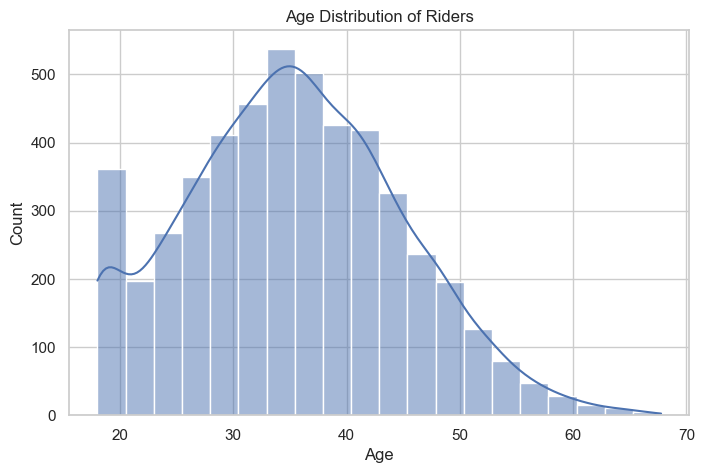

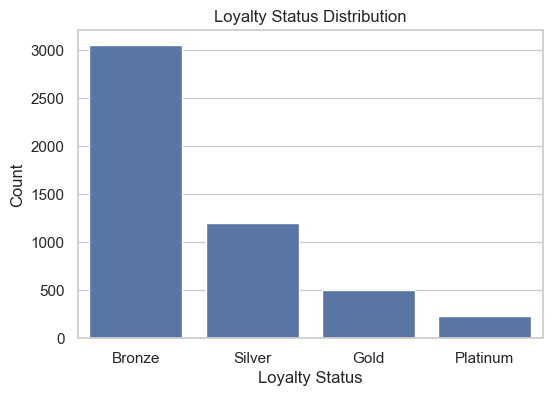

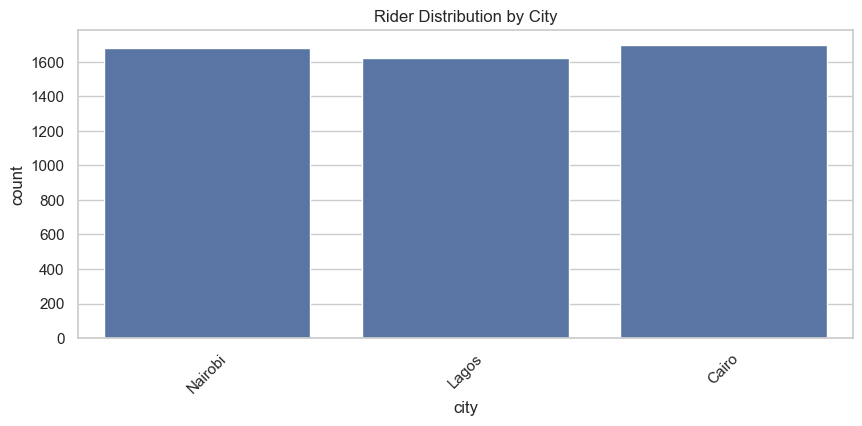

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(riders['age'], bins=20, kde=True)
plt.title("Age Distribution of Riders")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Loyalty status distribution
plt.figure(figsize=(6,4))
sns.countplot(data=riders, x='loyalty_status')
plt.title("Loyalty Status Distribution")
plt.xlabel("Loyalty Status")
plt.ylabel("Count")
plt.show()

# City distribution
plt.figure(figsize=(10,4))
sns.countplot(data=riders, x='city')
plt.title("Rider Distribution by City")
plt.xticks(rotation=45)
plt.show()


#### Age Distribution of Riders — Brief Insight
The age distribution shows that most riders fall between their late 20s and early 40s, with a clear peak around the mid‑30s. This suggests the platform is most popular among working‑age adults who rely on ride‑hailing for commuting and daily mobility. Very young and older age groups appear less represented, indicating different mobility needs or lower adoption in those segments.

#### Loyalty Status Distribution — Brief Insight
The loyalty tiers are heavily skewed toward Bronze, with progressively fewer riders in Silver, Gold, and Platinum. This pattern is typical for tier‑based systems, where most users remain in the entry tier. It highlights an opportunity to improve retention and engagement strategies aimed at moving riders from Bronze into higher tiers.

#### Rider Distribution by City — Brief Insight

Rider counts across Nairobi, Lagos, and Cairo are relatively balanced, with Nairobi and Cairo slightly ahead. This indicates healthy multi‑city adoption and suggests that behavioural patterns and churn analysis should consider city‑level differences, as each market may have unique usage drivers and operational conditions.

#### 6.2 Trip Behaviour Patterns

Trip behaviour analysis is performed on the full trips dataset to capture complete rider behaviour across all cities and time periods.

In [21]:
# changing both columns to datetime 
trips['trip_time'] = pd.to_datetime(
    trips['trip_time'],
    utc=True,
    errors='coerce'
)

trips['dropoff_time'] = pd.to_datetime(
    trips['dropoff_time'],
    utc=True,
    errors='coerce'
)

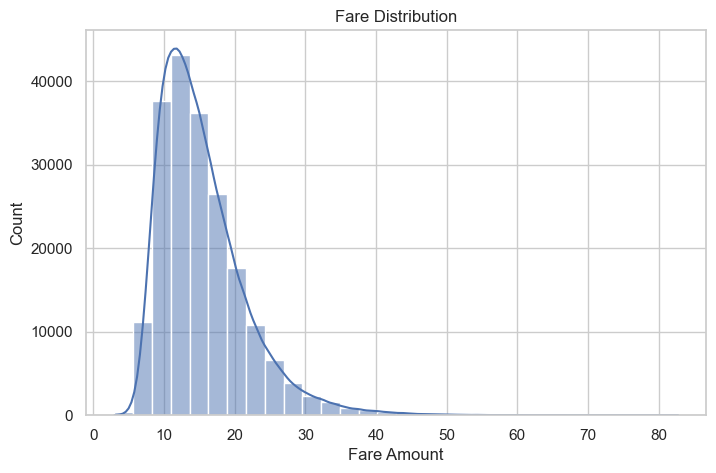

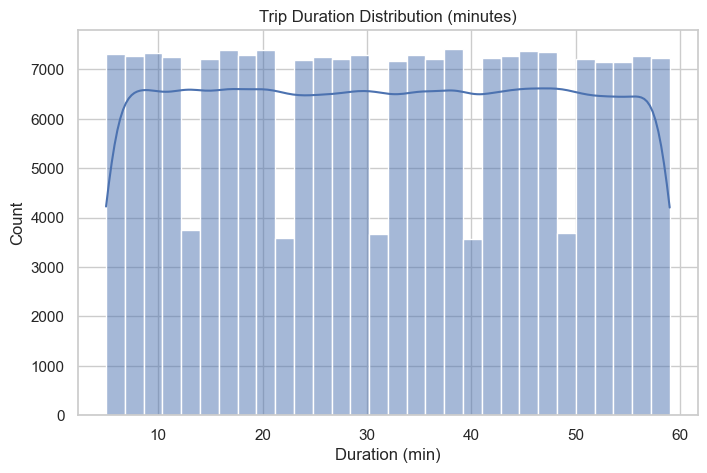

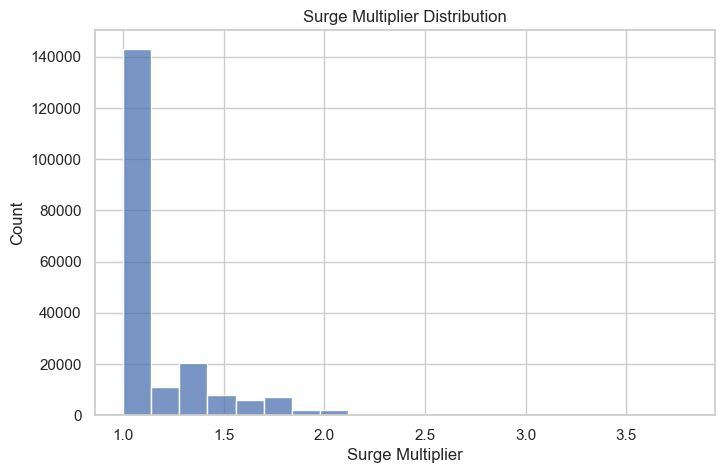

In [22]:
# Trip fare distribution
plt.figure(figsize=(8,5))
sns.histplot(trips['fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Count")
plt.show()

# Trip duration (in minutes)
trips['trip_duration'] = (
    trips['dropoff_time'] - trips['trip_time']
).dt.total_seconds() / 60

plt.figure(figsize=(8,5))
sns.histplot(trips['trip_duration'], bins=30, kde=True)
plt.title("Trip Duration Distribution (minutes)")
plt.xlabel("Duration (min)")
plt.ylabel("Count")
plt.show()

# Surge multiplier distribution
plt.figure(figsize=(8,5))
sns.histplot(trips['surge_multiplier'], bins=20, kde=False)
plt.title("Surge Multiplier Distribution")
plt.xlabel("Surge Multiplier")
plt.ylabel("Count")
plt.show()

#### Insights

##### Fare Distribution — Brief Insight
The fare distribution is right‑skewed, with most trips priced in the lower range. This indicates that short, low‑cost rides dominate rider behaviour, which is typical for urban mobility platforms. A smaller number of higher‑fare trips form a long tail, representing less frequent long‑distance or premium journeys.

##### Trip Duration Distribution — Brief Insight
Trip durations are concentrated in the short‑to‑medium range, reflecting common city travel patterns. The smooth distribution suggests consistent trip behaviour across the full dataset, with longer trips forming a smaller proportion of overall activity.Trip durations are concentrated in the short‑to‑medium range, reflecting common city travel patterns. The relatively even spread with periodic dips may indicate operational or data‑collection patterns. Overall, riders tend to take quick point‑to‑point trips, reinforcing the platform’s role in everyday mobility.
Trip duration was derived using pickup and drop‑off timestamps and expressed in minutes for interpretability


##### Surge Multiplier Distribution — Brief Insight
Most trips occur at a surge multiplier of 1.0, indicating that riders typically travel during normal demand periods. Higher surge values are relatively rare and occur during peak demand windows, highlighting surge pricing as an occasional but important behavioural factor.


#### 6.3 Engagement Behaviour (Sessions)

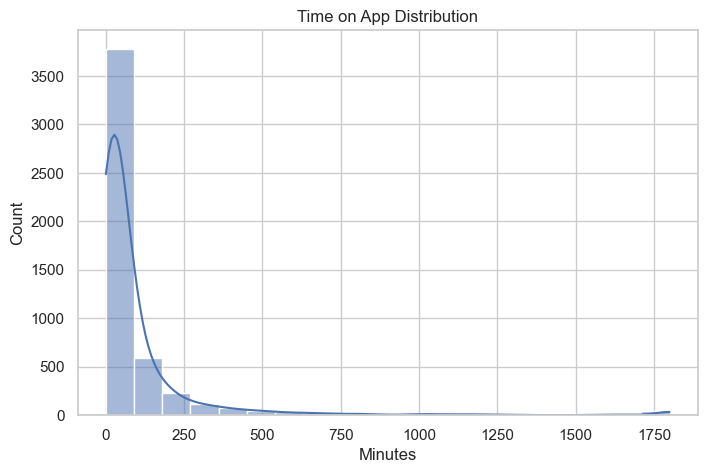

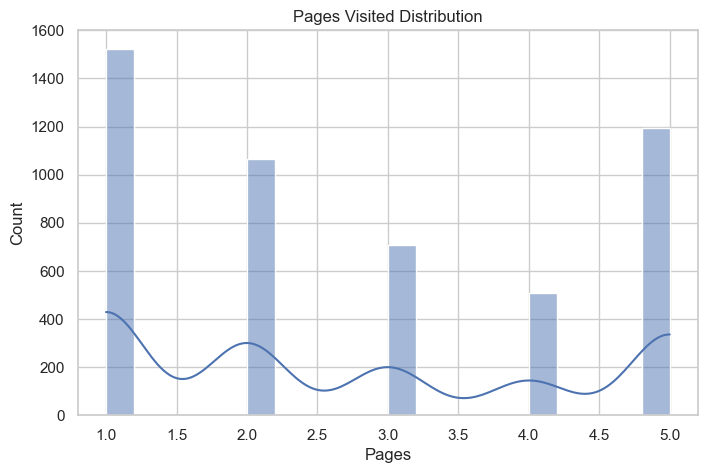

In [23]:
# Time on app
plt.figure(figsize=(8,5))
sns.histplot(sessions['time_on_app'], bins=20, kde=True)
plt.title("Time on App Distribution")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

# Pages visited
plt.figure(figsize=(8,5))
sns.histplot(sessions['pages_visited'], bins=20, kde=True)
plt.title("Pages Visited Distribution")
plt.xlabel("Pages")
plt.ylabel("Count")
plt.show()

##### Time on App Distribution — Brief Insight
Most sessions involve a short amount of time spent on the app, with a long right‑skew indicating that only a small number of users stay significantly longer. This suggests that riders typically complete tasks quickly—such as checking prices or booking a ride—while unusually long sessions may reflect browsing behaviour or difficulty finding a driver.

##### Pages Visited Distribution — Brief Insight
The number of pages visited per session is generally low, showing that riders navigate efficiently and complete actions with minimal exploration. The sharp drop‑off after one or two pages suggests focused behaviour, while higher page‑visit counts may indicate comparison activity or friction in the booking process.

In [24]:
# Conversion rate
conversion_rate = sessions['converted'].mean()
conversion_rate

0.155

##### Conversion Rate — Brief Insight

The average conversion rate is approximately 15.5%, meaning that most app sessions do not result in a completed action such as booking a ride. This suggests that sessions are often exploratory, involving price checks or browsing, and highlights potential friction points in the booking funnel.

#### 6.4 Correlation Matrix (Rider & Trip Features)

Trip‑level features were aggregated at the observation level for exploratory correlation analysis

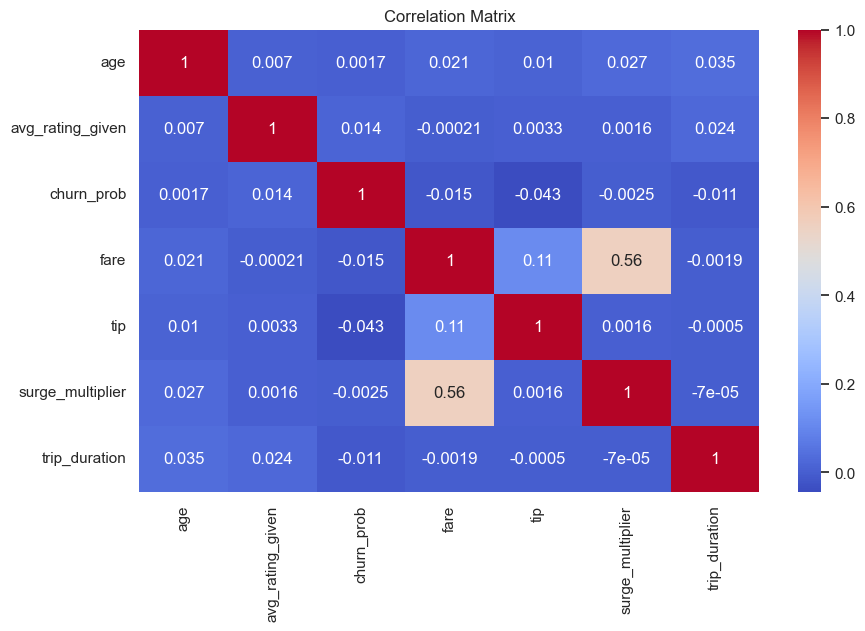

In [25]:
# Select numerical columns from riders + trips
numeric_cols = [
    'age', 'avg_rating_given', 'churn_prob',
    'fare', 'tip', 'surge_multiplier', 'trip_duration'
]

corr_data = pd.concat([
    riders[['age', 'avg_rating_given', 'churn_prob']],
    trips[['fare', 'tip', 'surge_multiplier', 'trip_duration']]
], axis=1)


plt.figure(figsize=(10,6))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##### Correlation Matrix — Brief Insight

The correlation matrix shows no strong linear relationships between individual rider demographics, trip features, and churn probability. Most correlations are close to zero, suggesting that churn behaviour is influenced by a combination of factors rather than any single variable in isolation.

#### 7. Feature Engineering
##### Objective
Transform raw trip and session level data into customer level behavioural features that can be used for:

* Customer segmentation

* Churn prediction

* RFM analysis

At this stage, all features are engineered at the rider (customer) level, ensuring one row per customer in the final modeling dataset.

#### 7.1 Trip‑Based Behavioural Features
##### Why Trip Features Matter
Trips represent the core value‑generating activity on the RideWise platform. Aggregating trip behaviour allows us to capture:

* Frequency of usage

* Monetary value contributed by each rider

* Recency of engagement

* Exposure to surge pricing

* Typical trip characteristics

These features form the foundation of both RFM metrics and churn risk signals.

##### Feature Definitions
For each rider, we compute:

* **Total Trips** – overall usage intensity

* **Total Spend** – lifetime monetary value

* **Average Fare** – typical trip cost

* **Average Trip Duration** – travel behaviour

* **Average Surge Multiplier** – exposure to peak pricing

* **Average Tip** – rider generosity / satisfaction proxy

* **Percentage of Surge Trips** – sensitivity to high‑demand periods

* **Days Since Last Trip** – recency indicator (critical for churn)

In [26]:
# 7.1 Trip-Based Feature Engineering

trip_features = (
    trips
    .groupby('user_id')
    .agg(
        total_trips=('trip_id', 'count'),
        total_spend=('fare', 'sum'),
        avg_fare=('fare', 'mean'),
        avg_tip=('tip', 'mean'),
        pct_surge_trips=('surge_multiplier', 'mean'),
        last_trip_date=('trip_time', 'max')
    )
    .reset_index()
)

reference_date = trips['trip_time'].max()
trip_features['days_since_last_trip'] = (
    reference_date - trip_features['last_trip_date']
).dt.days


Trip Behaviour Insights
Usage Frequency:  
Riders exhibit varying trip frequencies, ranging from low‑activity users (3–5 trips) to more engaged riders (10+ trips). This variation supports the need for segmentation based on usage intensity.

Monetary Value:  
Total spend scales proportionally with trip count, reinforcing the importance of frequency as a driver of customer lifetime value.

Recency Patterns:  
*days_since_last_trip* highlights a clear separation between recently active riders (10–15 days) and long‑inactive riders (100+ days). This feature will be central to churn definition and prediction.

Surge Exposure:  
Most riders experience low average surge multipliers, indicating that trips are primarily taken during off‑peak periods. However, a subset of riders shows higher surge exposure, which may influence satisfaction and retention.

Trip Duration:  
Average trip durations cluster around short‑to‑medium urban journeys, consistent with typical ride‑hailing usage patterns.

These features directly support:

**RFM Analysis**

Recency → days_since_last_trip

Frequency → total_trips

Monetary → total_spend

**Churn Modeling**

Long inactivity gaps signal elevated churn risk

Declining frequency and spend reinforce disengagement

**Customer Segmentation**

High‑frequency vs low‑frequency riders

Surge‑tolerant vs surge‑sensitive users

#### 7.2 Session‑Based Engagement Features
###### Objective
While trips capture *actual usage and revenue*, session data captures *engagement intent*. Many riders interact with the app without completing a trip, making session behaviour a valuable early indicator of:

* Engagement quality

* Friction in the booking process

* Potential churn risk

By aggregating session‑level data to the rider level, we enrich our understanding of customer behaviour beyond completed rides.

**Why Session Features Matter**

Session behaviour helps answer questions such as:

* How often do riders open the app?

* How deeply do they engage during each visit?

* How likely are they to convert intent into action?

These signals complement trip‑based features and improve both *segmentation* and *churn prediction accuracy*.

##### Feature Definitions
For each rider, we compute:

* *Total Sessions* – frequency of app engagement

* *Average Time on App* – depth of interaction

* *Average Pages Visited* – navigation complexity

* *Conversion Rate* – likelihood of completing a booking

* *Days Since Last Session* – engagement recency

In [27]:
# 7.2 Session-Based Feature Engineering

session_features = (
    sessions
    .groupby('rider_id')
    .agg(
        total_sessions=('session_id', 'count'),
        avg_time_on_app=('time_on_app', 'mean'),
        avg_pages_visited=('pages_visited', 'mean'),
        conversion_rate=('converted', 'mean'),
        last_session_date=('session_time', 'max')
    )
    .reset_index()
)

# Calculate engagement recency
reference_date = sessions['session_time'].max()
session_features['days_since_last_session'] = (
    reference_date - session_features['last_session_date']
).dt.days

session_features.head()


,rider_id,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,last_session_date,days_since_last_session
0,R00003,1,22.0,1.0,0.0,2025-04-27 05:56:39+00:00,0
1,R00005,1,22.0,1.0,0.0,2025-04-27 13:02:49+00:00,0
2,R00009,1,24.0,5.0,0.0,2025-04-27 00:32:12+00:00,0
3,R00010,2,2.5,4.0,0.0,2025-04-27 05:04:43+00:00,0
4,R00013,1,275.0,2.0,0.0,2025-04-27 09:50:28+00:00,0


##### **Session Engagement Insights**
* **Engagement Frequency**:  
Most riders in this subset have a very low number of sessions, often only one, indicating that app usage is generally infrequent and task‑focused rather than exploratory.

* **Time on App**:  
Session duration varies across riders, ranging from short interactions to occasional extended sessions. Longer sessions without conversion may reflect browsing behaviour, inactivity while the app remains open, or difficulty completing a booking.

* **Navigation Behaviour**:  
The number of pages visited per session is typically low, suggesting efficient navigation and focused usage. Higher page counts appear less frequently and may indicate comparison behaviour or friction during the booking process.


* **Conversion Patterns**:  
Several riders show zero conversion despite recent sessions, highlighting a group of engaged but non‑converting users. This aligns with the overall session analysis, where most sessions do not result in a completed action.

* **Engagement Recency**:  
The days_since_last_session metric shows that these riders were active on the most recent day in the dataset, capturing short‑term engagement and complementing trip‑based recency measures.

##### **Why Session Features Matter for Churn**
Session behaviour allows us to distinguish between:

* **Inactive riders** → no trips, no sessions or trips

* **Disengaged riders** → sessions without conversion

* **Engaged riders** → frequent sessions and trips

This distinction is critical for:

* More accurate churn risk assessment

* Behaviour‑driven customer segmentation

* Targeted retention and user experience improvements

#### **8. Master Customer Dataset Construction**

**Objective**
Combine all engineered customer‑level features into a single, unified master dataset that will serve as the foundation for:

* **RFM analysis**

* **Customer segmentation**

* **Churn labeling**

* **Predictive modeling**

At this stage, each row represents one rider, and all behavioural signals are aligned at the same grain.

##### **Why Consolidation Happens Here (and Only Here)**
Up to now:

* Trips were aggregated → trip_features

* Sessions were aggregated → session_features

* Rider attributes live in → riders

All three datasets are now:

* Clean

* Customer‑level

* Non‑duplicative

This is the only safe point to merge.

#### 8.1 Merging Customer‑Level Features

**Merge Strategy**

* riders is the base table

* Trip and session features are left‑joined

* This ensures all riders are retained, even if they have:

No trips

No sessions

In [28]:
# 8.1 Master Customer Dataset Construction

customer_master = (
    riders
    .merge(trip_features, on='user_id', how='left')
    .merge(
        session_features,
        left_on='user_id',
        right_on='rider_id',
        how='left'
    )
)

# Drop duplicate key column after merge
customer_master.drop(columns=['rider_id'], inplace=True)

customer_master.head()


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,total_trips,total_spend,...,avg_tip,pct_surge_trips,last_trip_date,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,last_session_date,days_since_last_session
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,25,366.05,...,0.161200,1.096000,2025-04-02 14:46:29+00:00,25,NaN,NaN,NaN,NaN,NaT,NaN
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,Not Referred,14,180.53,...,0.054286,1.071429,2025-04-22 04:35:17+00:00,5,NaN,NaN,NaN,NaN,NaT,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,Not Referred,24,378.99,...,0.217083,1.191667,2025-04-13 00:08:00+00:00,14,NaN,NaN,NaN,NaN,NaT,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,Not Referred,9,121.47,...,0.096667,1.155556,2025-02-25 04:22:32+00:00,61,1.0,22.0,1.0,0.0,2025-04-27 05:56:39+00:00,0.0
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,16,268.43,...,0.586250,1.262500,2025-04-15 05:30:04+00:00,12,NaN,NaN,NaN,NaN,NaT,NaN


#### 8.2 Post‑Merge Validation

##### Why Validation Matters

After consolidation, we must confirm:

No row duplication

Expected missing values only

Correct customer grain

In [29]:
# Shape and structure check
print("Customer Master Shape:", customer_master.shape)

# Check for duplicate customers
print("Duplicate user_ids:", customer_master['user_id'].duplicated().sum())

# Missing values overview
customer_master.isnull().sum()

Customer Master Shape: (5000, 21)
Duplicate user_ids: 0


user_id                       0
signup_date                   0
loyalty_status                0
age                           0
city                          0
avg_rating_given              0
churn_prob                    0
referred_by                   0
total_trips                   0
total_spend                   0
avg_fare                      0
avg_tip                       0
pct_surge_trips               0
last_trip_date                0
days_since_last_trip          0
total_sessions             3087
avg_time_on_app            3087
avg_pages_visited          3087
conversion_rate            3087
last_session_date          3087
days_since_last_session    3087
dtype: int64

##### **Master Dataset Insights**

The customer master dataset contains 5,000 unique riders and 21 engineered features, confirming that the merge process successfully consolidated demographic, trip, and session‑level information into a single rider‑level table

* No duplicate user_id values were detected, ensuring that each row represents a distinct rider and that downstream analysis will not be affected by duplication bias.

* Core rider and trip features are complete, with no missing values across:

   * Demographics (age, city, loyalty status)

   * Trip behaviour (total trips, spend, fare, surge exposure)

   * Trip recency (last trip date, days since last trip)

   * Churn probability

* Session‑based features contain substantial missing values, with over 3,000 riders lacking session metrics such as total sessions and average time on app. This reflects riders who completed trips without recent measurable app session activity, rather than data quality issues.

* The presence of both trip‑only riders and session‑active riders reinforces the importance of treating session engagement as a complementary behavioural signal rather than a universal requirement for platform usage.

#### 9. RFM Metrics & Churn Definition

**Objective**

Translate customer behaviour into actionable business signals by:

* Quantifying engagement using RFM metrics

* Defining churn in a way that aligns with business reality

* Preparing labels for supervised churn modeling

#### 9.1 RFM Metrics Construction

**Why RFM Matters**
RFM (Recency, Frequency, Monetary) is a proven framework for understanding customer value and engagement:

* **Recency** captures how recently a rider interacted with the platform (days_since_last_trip)

* **Frequency** reflects usage intensity (total_trips)

* **Monetary** measures customer value contribution (total_spend)

Together, these metrics form the backbone of both segmentation and churn prediction.

In [30]:
# 9.1 RFM Metrics

rfm = customer_master[['user_id', 'days_since_last_trip', 'total_trips', 'total_spend']].copy()

rfm.rename(columns={
    'days_since_last_trip': 'recency',
    'total_trips': 'frequency',
    'total_spend': 'monetary'
}, inplace=True)

rfm.head()

,user_id,recency,frequency,monetary
0,R00000,25,25,366.05
1,R00001,5,14,180.53
2,R00002,14,24,378.99
3,R00003,61,9,121.47
4,R00004,12,16,268.43


##### Initial RFM Observations

* Recency varies across riders, indicating a mix of recently active users and riders who have not taken a trip for an extended period.

* Frequency and monetary value move together, showing that riders who take more trips generally contribute higher total spend.

* Riders with low trip frequency, lower monetary value, and higher recency already stand out as potential churn‑risk candidates, based on reduced engagement and longer inactivity periods.

#### 9.2 Churn Definition

**Business Definition of Churn**

In alignment with the project objectives, churn is defined as:

**A rider who has not completed a trip in the last 30 days**

This definition:

* Reflects meaningful disengagement

* Enables proactive intervention

* Aligns with real‑world retention strategies

In [31]:
# 9.2 Churn Label Definition

customer_master['churn'] = (
    customer_master['days_since_last_trip'] > 30
).astype(int)

customer_master[['user_id', 'days_since_last_trip', 'churn']].head()

,user_id,days_since_last_trip,churn
0,R00000,25,0
1,R00001,5,0
2,R00002,14,0
3,R00003,61,1
4,R00004,12,0


**Churn Label Insights**

* Riders with long inactivity gaps are clearly identified as churned.

* Recently active riders are correctly labeled as non‑churned.

* This binary label provides a clean target variable for supervised learning models.

**9.3 Churn Distribution Check**

*Why This Matters*

* Before modeling, it’s important to understand class balance to:

* Anticipate modeling challenges

* Choose appropriate evaluation metrics

In [32]:
customer_master['churn'].value_counts(normalize=True)

0    0.8138
1    0.1862
Name: churn, dtype: float64

**Initial Churn Distribution Insight**

0 → Non‑churned riders  
Approximately 81.38% of riders are labeled as active (not churned).

1 → Churned riders  
Approximately 18.62% of riders are labeled as churned based on the inactivity threshold defined earlier.

**9.4 Visualizing RFM Metrics**

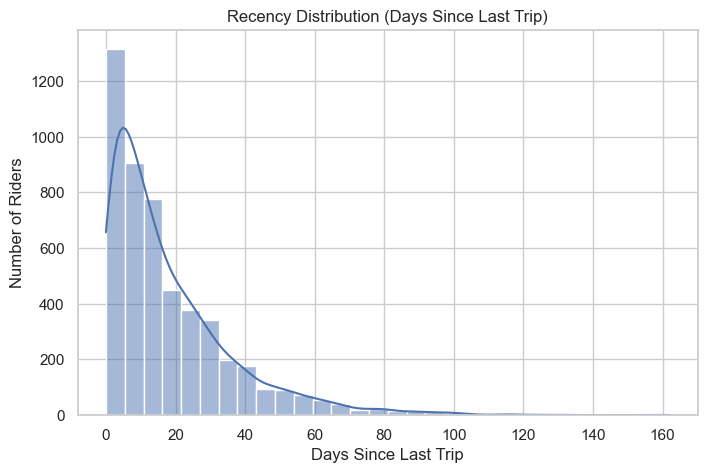

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(customer_master['days_since_last_trip'], bins=30, kde=True)
plt.title("Recency Distribution (Days Since Last Trip)")
plt.xlabel("Days Since Last Trip")
plt.ylabel("Number of Riders")
plt.show()

Insight:

The recency distribution is right‑skewed, with most riders having taken a trip recently, while a smaller group shows longer periods of inactivity. This pattern indicates that the majority of users remain active, but there is a meaningful tail of riders who may be at risk of churn as inactivity increases. Recency therefore serves as a strong behavioural signal for distinguishing active riders from disengaged ones.

**Frequency Distribution**

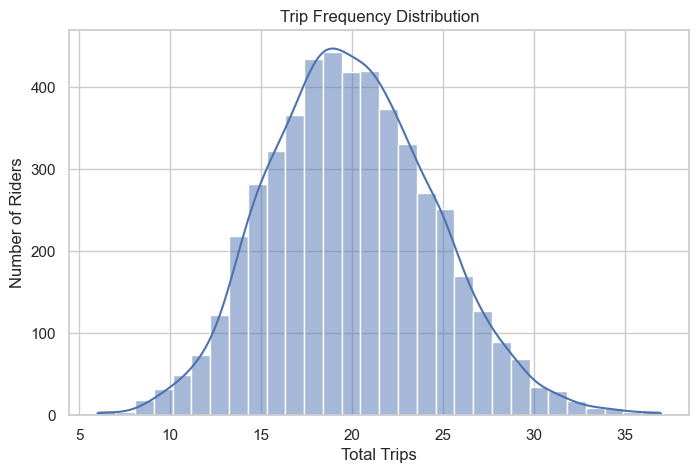

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(customer_master['total_trips'], bins=30, kde=True)
plt.title("Trip Frequency Distribution")
plt.xlabel("Total Trips")
plt.ylabel("Number of Riders")
plt.show()

**Trip Frequency Distribution Insight**

The trip frequency distribution is centered around a moderate number of trips, with most riders completing a similar range of journeys. This suggests a stable core of regularly active users rather than extreme usage patterns. Riders at the lower end of the distribution may represent occasional users, while those with higher trip counts indicate sustained engagement and higher customer value.

This pattern supports the use of frequency as a key behavioural feature for segmentation and churn analysis, as it clearly differentiates casual riders from consistently active ones

**Monetary Distribution**

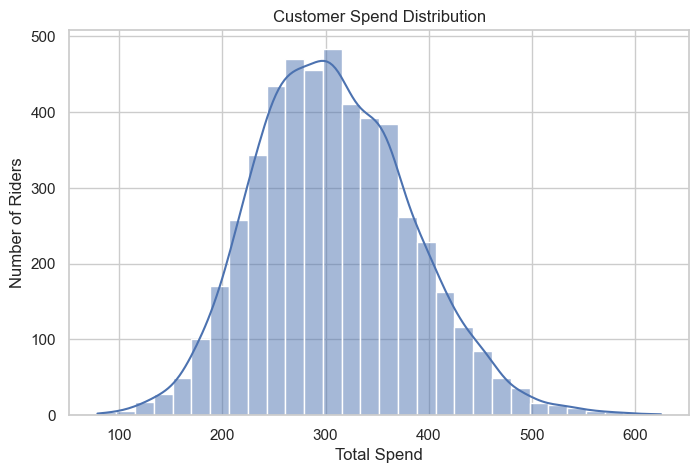

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(customer_master['total_spend'], bins=30, kde=True)
plt.title("Customer Spend Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Riders")
plt.show()

**Customer Spend Distribution Insight**

Customer spend is concentrated around a mid‑range value, with most riders contributing a similar total amount over time. This suggests that overall revenue is driven by a broad base of moderately active users rather than a small group of extreme spenders. Riders at the lower end of the distribution likely reflect occasional usage, while higher spenders indicate sustained engagement and higher lifetime value.

This pattern supports the use of monetary value as a meaningful feature for segmentation and churn analysis, as it helps distinguish between casual and consistently valuable riders.

#### 9.5 Visualizing Churn Behaviour

Churn vs Recency

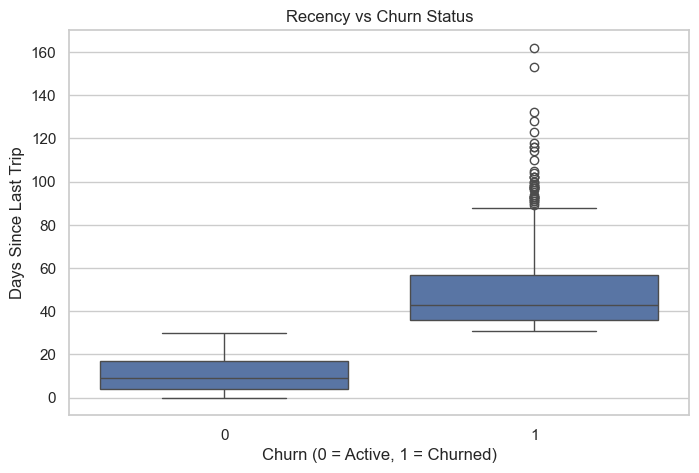

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='churn',
    y='days_since_last_trip',
    data=customer_master
)
plt.title("Recency vs Churn Status")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Days Since Last Trip")
plt.show()

**Recency vs Churn Insight**

The comparison between recency and churn status shows a clear separation between active and churned riders. Active riders tend to have much lower days since last trip, indicating recent engagement, while churned riders show significantly longer inactivity periods with a wider spread. This confirms that recency is a strong behavioural indicator of churn, validating its use both for churn labeling and as a key feature in predictive modelling.

#### 9.6 Churn Rate Overview

##### Simple Churn Breakdown

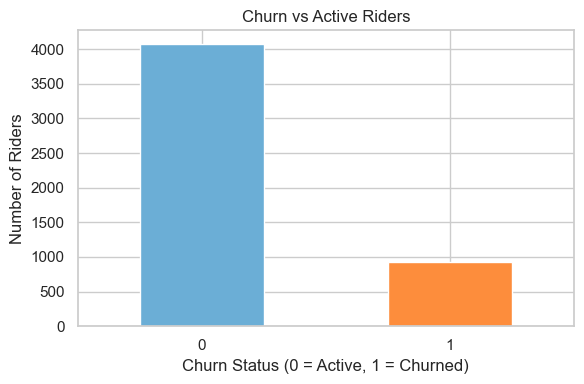

In [37]:
plt.figure(figsize=(6,4))

customer_master['churn'].value_counts().plot(
    kind='bar',
    color=['#6BAED6', '#FD8D3C']
)

plt.title("Churn vs Active Riders")
plt.xlabel("Churn Status (0 = Active, 1 = Churned)")
plt.ylabel("Number of Riders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### **Step 10: Customer Segmentation Using RFM**

##### Objective
Group riders into meaningful behavioural segments based on their:

* Recency

* Frequency

* Monetary value

These segments will:

* Guide retention strategies

* Inform marketing decisions

* Provide context for churn prediction


#### **Why Segmentation Comes Before Modeling**
Segmentation:

* Makes churn results interpretable

* Helps explain why customers churn

* Allows targeted interventions instead of one‑size‑fits‑all actions

* This mirrors how real companies operate.

#### **10.1 Preparing RFM Data for Clustering**

**Why Scaling Is Required**

RFM features are on different scales:

* Recency → days

* Frequency → counts

* Monetary → currency

Clustering algorithms are distance‑based, so we standardize the data

In [38]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[['recency', 'frequency', 'monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

#### **10.2 Choosing the Number of Segments (Elbow Method)**

**Why This Matters**
We want:

* Enough segments to capture behaviour

* Not so many that interpretation becomes difficult

#### **Step 10.1 : Filter Valid RFM Customers**

In [39]:
# Remove riders with no trip history for RFM segmentation
rfm_clean = rfm.dropna(subset=['recency', 'frequency', 'monetary']).copy()

rfm_clean.shape

(5000, 4)

#### Step 10.2: Scale the Clean RFM Data

In [40]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm_clean[['recency', 'frequency', 'monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

#### **Step 10.3: Elbow Method**

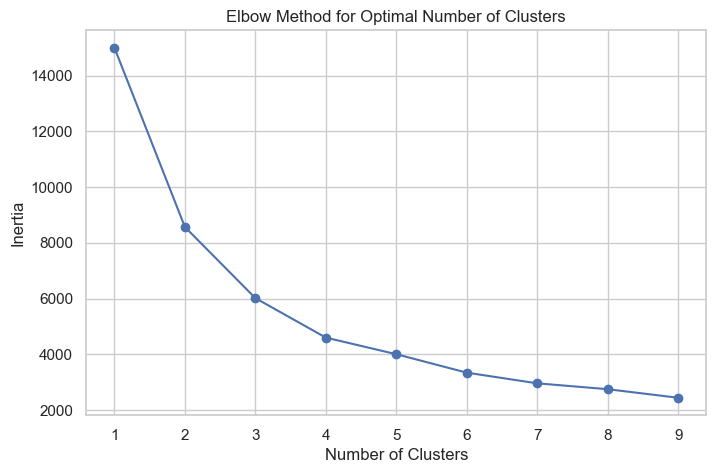

In [41]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


##### Elbow Method Insight

The elbow plot shows a sharp drop in inertia up to around three clusters, after which the rate of improvement slows noticeably. This suggests that three clusters provide a good balance between capturing meaningful structure in the data and avoiding unnecessary complexity. Adding more clusters beyond this point yields diminishing returns, making three a reasonable choice for customer segmentation.

**Why 3 Clusters Is the Right Choice (Business Logic)**
Three segments naturally map to how companies think about customers:

1. Low‑engagement / At‑risk users

2. Regular / Stable users

3. High‑value / Loyal users

#### **10.4 Applying K‑Means Clustering**

**Objective**

Assign each rider with valid RFM metrics to a behavioural segment using K‑Means clustering, based on the optimal number of clusters identified via the elbow method.

At this stage:

* Only riders with completed trips are included

* Each rider is assigned to one of three segments

In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_clean['segment'] = kmeans.fit_predict(rfm_scaled)

rfm_clean.head()

,user_id,recency,frequency,monetary,segment
0,R00000,25,25,366.05,2
1,R00001,5,14,180.53,1
2,R00002,14,24,378.99,2
3,R00003,61,9,121.47,0
4,R00004,12,16,268.43,1


**Why This Step Matters**

This step transforms abstract RFM metrics into actionable customer groups, enabling:

* Targeted retention strategies

* Segment‑specific churn analysis

* Business‑friendly interpretation of customer behaviour

#### **10.5 Segment Profiling and Interpretation**

Objective

Understand the behavioural characteristics of each segment by analysing average RFM values and segment size.

In [43]:
# Segment Summary Table 
segment_summary = (
    rfm_clean
    .groupby('segment')
    .agg(
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        customer_count=('user_id', 'count')
    )
    .reset_index()
)

segment_summary

,segment,avg_recency,avg_frequency,avg_monetary,customer_count
0,0,53.160000,17.027143,261.056957,700
1,1,12.061860,17.115710,259.151504,2247
2,2,13.005845,24.194350,378.030804,2053


#### **Segment 0 – Low Engagement / At‑Risk Riders**
(Segment ID: 0)

**Behaviour Profile**

* Highest average recency (53 days since last trip)

* Lower trip frequency compared to other segments

* Lowest average spend 

* Smallest segment (700 riders)

**Interpretation**

Riders in this segment show reduced engagement and longer inactivity periods relative to other groups. While not all may be fully churned, their behaviour suggests early‑stage disengagement and an elevated risk of churn if inactivity continues.

**Business Action**

* Light‑touch re‑engagement campaigns

* Targeted reminders or incentives to encourage return usage

* Monitor closely rather than heavy retention investment

Churn Alignment
This segment overlaps strongly with churn‑prone behaviour, but should be viewed as at‑risk rather than definitively churned.

#### **Segment 2 – High‑Value / Loyal Riders**

**(Segment ID: 2)**

**Behaviour Profile**

* Low average recency (13 days since last trip

* Highest trip frequency (24 trips)

* Highest average spend (378)

* Large segment size (2,053 riders)

**Interpretation**

This segment represents the most engaged and valuable riders. They use the platform frequently, spend significantly more than other groups, and remain consistently active. Their behaviour indicates strong loyalty and high lifetime value.

**Business Action**

* Priority retention and loyalty programmes

* Premium rewards and personalised experiences

* Service quality protection to prevent dissatisfaction

 Losing even a small proportion of this segment would have a disproportionate revenue impact.

#### **Segment 1 – Regular / Mid‑Value Riders**

**(Segment ID: 1)**

**Behaviour Profile**

* Low to low recency (12 days)

* Moderate trip frequency (17 trips)

* Largest segment (2,247 riders)


**Interpretation**

These riders form the core user base. They are consistently active but not as intensive in usage or spend as the high‑value segment. With the right engagement strategies, many riders in this group could be nurtured into higher‑value behaviour.

**Business Action**

* Loyalty nudges and personalised promotions

* Engagement reminders to reinforce usage habits

* Upsell and cross‑sell opportunities

 This segment is critical for long‑term retention and growth.

In [44]:
#Rename Segments for Clarity
segment_labels = {
    0: "High-Value Riders",
    1: "At-Risk Riders",
    2: "Regular Riders"
}

rfm_clean['segment_label'] = rfm_clean['segment'].map(segment_labels)

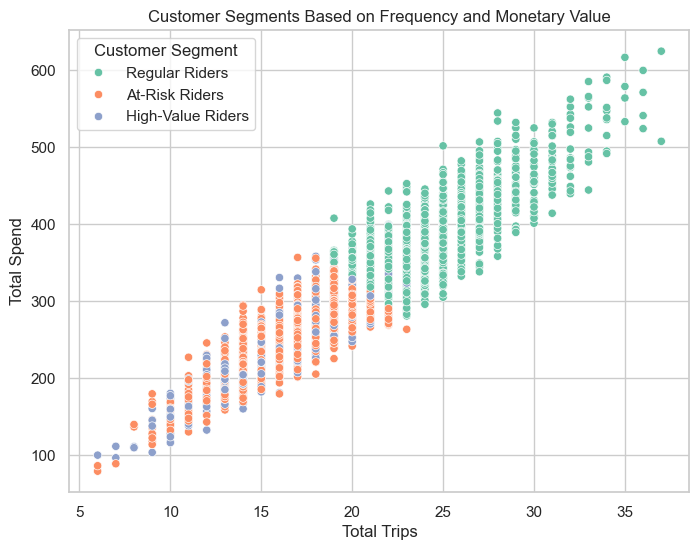

In [45]:
# Segmentation Visualisation Code 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm_clean,
    x='frequency',
    y='monetary',
    hue='segment_label',
    palette='Set2'
)
plt.title("Customer Segments Based on Frequency and Monetary Value")
plt.xlabel("Total Trips")
plt.ylabel("Total Spend")
plt.legend(title="Customer Segment")
plt.show()


##### Visual Interpretation

High‑value riders are concentrated in the upper‑right region, reflecting higher trip frequency and greater overall spend.

Regular riders occupy the middle range, indicating consistent but moderate engagement with the platform.

At‑risk riders are clustered toward the lower‑left region, showing lower usage and lower spend relative to other segments.

The visible separation between these groups supports the effectiveness of RFM‑based clustering in capturing meaningful differences in customer behaviour

In [46]:
import os

os.makedirs("data/processed", exist_ok=True)

customer_master.to_csv(
    "data/processed/customer_features.csv",
    index=False
)

In [48]:
pd.read_csv("data/processed/customer_features.csv").head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,total_trips,total_spend,...,pct_surge_trips,last_trip_date,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,last_session_date,days_since_last_session,churn
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,25,366.05,...,1.096000,2025-04-02 14:46:29+00:00,25,NaN,NaN,NaN,NaN,NaN,NaN,0
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,Not Referred,14,180.53,...,1.071429,2025-04-22 04:35:17+00:00,5,NaN,NaN,NaN,NaN,NaN,NaN,0
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,Not Referred,24,378.99,...,1.191667,2025-04-13 00:08:00+00:00,14,NaN,NaN,NaN,NaN,NaN,NaN,0
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,Not Referred,9,121.47,...,1.155556,2025-02-25 04:22:32+00:00,61,1.0,22.0,1.0,0.0,2025-04-27 05:56:39+00:00,0.0,1
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,16,268.43,...,1.262500,2025-04-15 05:30:04+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,0


In [49]:
import os
os.path.exists("data/processed/customer_features.csv")


True

#### **11 – Churn Prediction Modeling**

**Objective**

Build a predictive model that estimates the probability of customer churn using behavioural features derived earlier in the analysis. This enables proactive retention strategies rather than reactive analysis.

#### **11.1 Modelling Dataset Preparation**
At this stage, the dataset already contains:

* A clearly defined churn label

* Behavioural features derived from customer activity

**Target Variable**
* churn

   * Binary outcome indicating whether a rider has churned

**Feature Set (Initial Baseline)**
We begin with a clean, interpretable feature set:

* recency

* frequency

* monetary

These features are:

* Behaviourally meaningful

* Non‑leaky

* Strong predictors of churn in subscription and usage‑based businesses

In [55]:
# Feature matrix and target variable
X = customer_master[
    ['days_since_last_trip', 'total_trips', 'total_spend']
]
y = customer_master['churn']

#### **11.2 Train–Test Split**

To evaluate generalisation performance, the data will be split into training and test sets.

Key considerations:

* Preserve class distribution using **stratification**

* Hold out test data for unbiased evaluation

This ensures the model is assessed on unseen customers, mirroring real‑world deployment.

In [56]:
#Train–Test Split (Stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### **11.3 Baseline Model: Logistic Regression**

I'll start with logistic regression because it:

* Provides strong baseline performance

* Is highly interpretable

* Allows direct insight into churn drivers

This model will help answer:

* Which behaviours increase churn risk?

* How strongly does recency dominate churn probability?




In [57]:
#Scaling (Required for Logistic Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **11.4 Model Evaluation Strategy**
Because churn is class‑imbalanced, evaluation will focus on metrics beyond accuracy:

* Precision

* Recall

* F1‑score

* ROC‑AUC

* Confusion matrix

This ensures the model balances:

* Catching churners early

* Avoiding excessive false positives

In [58]:
#Train Baseline Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### **11.5 Next Steps After Baseline**

Once the baseline is validated:

Compare against a tree‑based model (Random Forest / Gradient Boosting)

Analyse feature importance

Integrate churn risk with customer segments

Package the model for API and Streamlit deployment

In [59]:
#Predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [60]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       814
           1       0.96      1.00      0.98       186

    accuracy                           0.99      1000
   macro avg       0.98      1.00      0.99      1000
weighted avg       0.99      0.99      0.99      1000



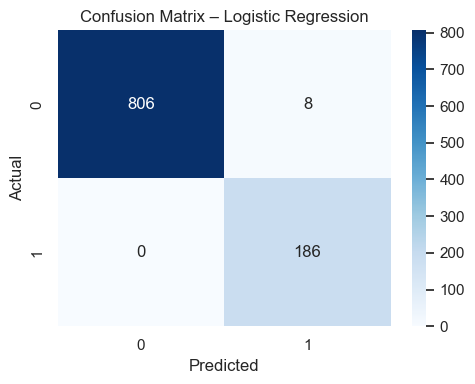

In [61]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.show()

In [62]:
#ROC‑AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 1.000
